# Discretized MPC for a 1D Point Robot with Classical and QAOA Solvers

This notebook is a presentation-friendly proof of concept for reformulating a tiny model-predictive control problem as a binary optimization problem and then solving it with both classical methods and QAOA in Qiskit.

Pipeline:

1. Define a 1D point-robot MPC problem with discretized controls.
2. Solve it exactly by brute force for ground truth.
3. Encode the controls with one-hot binary variables.
4. Assemble the MPC objective into a QUBO.
5. Convert `QuadraticProgram -> QUBO -> Ising` in Qiskit.
6. Solve the QUBO exactly and approximately with QAOA.
7. Reuse the one-shot solver inside a receding-horizon closed-loop MPC simulation.

Why this matters:

- Standard continuous MPC is usually solved by continuous optimization, not by QAOA.
- Discretizing the control turns the planning problem into a finite combinatorial search.
- One-hot penalties let us embed action-selection constraints into a purely quadratic binary objective.
- QAOA operates on the corresponding Ising Hamiltonian, not directly on the raw MPC equations.
- This is a proof of concept, not a practical real-time quantum controller.

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import numpy as np
from IPython.display import Image, display

from mpc_qaoa_demo import (
    MPCParams,
    ACTIONS,
    brute_force_baseline,
    build_manual_qubo,
    build_qiskit_qubo,
    check_qiskit_available,
    decode_binary_vector,
    encode_control_sequence,
    format_bitstring,
    penalty_feasibility_experiment,
    print_binary_encoding_demo,
    print_problem_story,
    print_qubo_summary,
    print_qiskit_model_summary,
    print_solver_outcome,
    rollout_dynamics,
    run_closed_loop,
    save_closed_loop_plots,
    save_closed_loop_animation,
    save_one_shot_plots,
    solve_qubo_exact_qiskit,
    solve_qubo_qaoa,
    validate_one_hot,
)

check_qiskit_available()

params = MPCParams(
    dt=1.0,
    horizon=3,
    p0=-2.0,
    v0=0.0,
    p_ref=5.0,
    q_p=1.0,
    q_v=0.2,
    r=0.1,
    q_pf=4.0,
    q_vf=1.0,
    lambda_onehot=25.0,
)

qaoa_reps = 1
qaoa_maxiter = 20
seed = 7
closed_loop_steps = 6
output_dir = Path('outputs_mpc_qaoa_notebook')

print_problem_story(params)


1. Robotics Problem Definition
Continuous MPC is typically posed over continuous control variables and solved
with continuous optimization routines. That is not naturally a QAOA problem.
Here we discretize the control set to {-1, 0, +1}, which turns the MPC action
selection into a finite combinatorial search over control sequences.

Horizon N = 3, dt = 1.0
Initial state: p0 = -2.0, v0 = 0.0
Reference: p_ref = 5.0, terminal velocity target = 0
Weights: q_p=1.0, q_v=0.2, r=0.1, q_pf=4.0, q_vf=1.0
One-hot penalty lambda = 25.0


## 2. Exact Brute-Force Baseline

In [2]:
baseline = brute_force_baseline(params)
baseline.rollout.controls, baseline.rollout.total_cost, baseline.runtime_s

([1, 1, -1], 200.3, 7.17999992048135e-05)

In [3]:
print(f'Enumerated sequences: {baseline.evaluated_sequences}')
print(f'Best exact sequence: {baseline.rollout.controls}')
print(f'Best exact cost: {baseline.rollout.total_cost:.6f}')
print(f'Positions: {np.round(baseline.rollout.positions, 3).tolist()}')
print(f'Velocities: {np.round(baseline.rollout.velocities, 3).tolist()}')

Enumerated sequences: 27
Best exact sequence: [1, 1, -1]
Best exact cost: 200.300000
Positions: [-2.0, -2.0, -1.0, 1.0]
Velocities: [0.0, 1.0, 2.0, 1.0]


## 3. Binary Encoding

In [4]:
encoded = encode_control_sequence(baseline.rollout.controls, params.horizon)
decoded = decode_binary_vector(encoded, params.horizon)

print_binary_encoding_demo(params, baseline.rollout.controls)
print(f'Encoded bitstring: {format_bitstring(encoded)}')
print(f'Decoded controls: {decoded}')
print(f'Feasible: {validate_one_hot(encoded, params.horizon)}')


3. Binary Encoding
Each timestep has three binary variables:
  k=0: ['z_0_m1', 'z_0_0', 'z_0_p1'], one-hot sum must equal 1
  k=1: ['z_1_m1', 'z_1_0', 'z_1_p1'], one-hot sum must equal 1
  k=2: ['z_2_m1', 'z_2_0', 'z_2_p1'], one-hot sum must equal 1

Example exact-optimal control sequence: [1, 1, -1]
Encoded one-hot bits: [0, 0, 1, 0, 0, 1, 1, 0, 0]
Encoded bitstring: 001001100
Decoding gives: [1, 1, -1]
One-hot feasible: True
Encoded bitstring: 001001100
Decoded controls: [1, 1, -1]
Feasible: True


## 4. Manual QUBO Construction

In [5]:
manual_qubo = build_manual_qubo(params)
print_qubo_summary(manual_qubo)
manual_qubo.qubo_matrix


4. Manual QUBO Construction
The QUBO objective is a quadratic polynomial over binary variables only.
One-hot constraints are enforced as quadratic penalties of the form
lambda * (z_{k,-1} + z_{k,0} + z_{k,+1} - 1)^2.

Number of binary variables: 9
Variable names: ['z_0_m1', 'z_0_0', 'z_0_p1', 'z_1_m1', 'z_1_0', 'z_1_p1', 'z_2_m1', 'z_2_0', 'z_2_p1']
Penalty weight: 25.0
QUBO constant term: 418.000000

Upper-triangular readable QUBO matrix Q where
J(z) = constant + sum_i Q_ii z_i + sum_{i<j} Q_ij z_i z_j
[[ 119.5   50.    13.    18.4    0.   -18.4    2.     0.    -2. ]
 [   0.   -25.    50.     0.     0.     0.     0.     0.     0. ]
 [   0.     0.  -132.5  -18.4    0.    18.4   -2.     0.     2. ]
 [   0.     0.     0.    36.3   50.    39.4    2.     0.    -2. ]
 [   0.     0.     0.     0.   -25.    50.     0.     0.     0. ]
 [   0.     0.     0.     0.     0.   -75.7   -2.     0.     2. ]
 [   0.     0.     0.     0.     0.     0.   -23.9   50.    47.8]
 [   0.     0.     0.     0.

array([[ 119.5,   50. ,   13. ,   18.4,    0. ,  -18.4,    2. ,    0. ,
          -2. ],
       [   0. ,  -25. ,   50. ,    0. ,    0. ,    0. ,    0. ,    0. ,
           0. ],
       [   0. ,    0. , -132.5,  -18.4,    0. ,   18.4,   -2. ,    0. ,
           2. ],
       [   0. ,    0. ,    0. ,   36.3,   50. ,   39.4,    2. ,    0. ,
          -2. ],
       [   0. ,    0. ,    0. ,    0. ,  -25. ,   50. ,    0. ,    0. ,
           0. ],
       [   0. ,    0. ,    0. ,    0. ,    0. ,  -75.7,   -2. ,    0. ,
           2. ],
       [   0. ,    0. ,    0. ,    0. ,    0. ,    0. ,  -23.9,   50. ,
          47.8],
       [   0. ,    0. ,    0. ,    0. ,    0. ,    0. ,    0. ,  -25. ,
          50. ],
       [   0. ,    0. ,    0. ,    0. ,    0. ,    0. ,    0. ,    0. ,
         -23.9]])

The one-hot constraints are added as quadratic penalties so the objective is purely a QUBO over binary variables. This is the form needed before mapping to an Ising Hamiltonian.

## 5. Penalty Sensitivity

In [6]:
penalty_results = penalty_feasibility_experiment(params, [0.5, 2.0, params.lambda_onehot])
for penalty, feasible, bits, value in penalty_results:
    print(
        f'lambda={penalty:>6.2f} -> feasible optimum={feasible}, '
        f'best bitstring={format_bitstring(bits)}, qubo_value={value:.6f}'
    )

lambda=  0.50 -> feasible optimum=True, best bitstring=001001100, qubo_value=200.300000
lambda=  2.00 -> feasible optimum=True, best bitstring=001001100, qubo_value=200.300000
lambda= 25.00 -> feasible optimum=True, best bitstring=001001100, qubo_value=200.300000


## 6. Qiskit Model and Ising Conversion

In [7]:
qp, qubo, qubit_op, offset = print_qiskit_model_summary(params)


5. Qiskit Model -> QUBO -> Ising
QuadraticProgram with explicit one-hot equality constraints:
Problem name: discretized_point_robot_mpc

Minimize
  -37*z_0_m1*z_0_p1 + 18.4*z_0_m1*z_1_m1 - 18.4*z_0_m1*z_1_p1 + 2*z_0_m1*z_2_m1
  - 2*z_0_m1*z_2_p1 - 18.4*z_0_p1*z_1_m1 + 18.4*z_0_p1*z_1_p1 - 2*z_0_p1*z_2_m1
  + 2*z_0_p1*z_2_p1 - 10.6*z_1_m1*z_1_p1 + 2*z_1_m1*z_2_m1 - 2*z_1_m1*z_2_p1
  - 2*z_1_p1*z_2_m1 + 2*z_1_p1*z_2_p1 - 2.2*z_2_m1*z_2_p1 + 144.5*z_0_m1
  - 107.5*z_0_p1 + 61.3*z_1_m1 - 50.7*z_1_p1 + 1.1*z_2_m1 + 1.1*z_2_p1 + 343

Subject to
  Linear constraints (3)
    z_0_0 + z_0_m1 + z_0_p1 == 1  'onehot_0'
    z_1_0 + z_1_m1 + z_1_p1 == 1  'onehot_1'
    z_2_0 + z_2_m1 + z_2_p1 == 1  'onehot_2'

  Binary variables (9)
    z_0_m1 z_0_0 z_0_p1 z_1_m1 z_1_0 z_1_p1 z_2_m1 z_2_0 z_2_p1


Converted QUBO:
Problem name: discretized_point_robot_mpc

Minimize
  25*z_0_0^2 + 50*z_0_0*z_0_p1 + 50*z_0_m1*z_0_0 + 25*z_0_m1^2
  + 13*z_0_m1*z_0_p1 + 18.4*z_0_m1*z_1_m1 - 18.4*z_0_m1*z_1_p1 + 2*z_0_m1

QAOA targets the Ising Hamiltonian because binary variables can be mapped to spin variables in `{ -1, +1 }`, and those spins map naturally to Pauli `Z` operators on qubits.

## 7. Classical Exact QUBO Solve

In [8]:
exact_outcome = solve_qubo_exact_qiskit(params, manual_qubo)
print_solver_outcome(exact_outcome, exact_cost=baseline.rollout.total_cost)


Solver Result: Exact QUBO (Qiskit)
Bitstring: 001001100
One-hot feasible: True
Decoded control sequence: [1, 1, -1]
QUBO objective: 200.300000
MPC cost: 200.300000
Approximation gap vs exact: 0.000000
Relative gap vs exact: 0.000%
Runtime: 0.009163 s
Extra info: {'solver_status': 'OptimizationResultStatus.SUCCESS'}
Positions: [-2.0, -2.0, -1.0, 1.0]
Velocities: [0.0, 1.0, 2.0, 1.0]


## 8. QAOA Solve

In [9]:
qaoa_outcome = solve_qubo_qaoa(
    params,
    manual_qubo,
    reps=qaoa_reps,
    maxiter=qaoa_maxiter,
    seed=seed,
)
print_solver_outcome(qaoa_outcome, exact_cost=baseline.rollout.total_cost)

c:\Users\ojasm\.conda\envs\mpc-qaoa-demo\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\ojasm\.conda\envs\mpc-qaoa-demo\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\ojasm\.conda\envs\mpc-qaoa-demo\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])



Solver Result: QAOA reps=1
Bitstring: 001001010
One-hot feasible: True
Decoded control sequence: [1, 1, 0]
QUBO objective: 203.200000
MPC cost: 203.200000
Approximation gap vs exact: 2.900000
Relative gap vs exact: 1.448%
Runtime: 36.197267 s
Extra info: {'reps': 1, 'solver_status': 'OptimizationResultStatus.SUCCESS', 'num_samples': 202}
Positions: [-2.0, -2.0, -1.0, 1.0]
Velocities: [0.0, 1.0, 2.0, 2.0]


## 9. Receding-Horizon MPC Closed Loop

In [10]:
exact_loop = run_closed_loop(
    name='Exact Receding-Horizon MPC',
    params=params,
    steps=closed_loop_steps,
    solver_factory=lambda step_params: solve_qubo_exact_qiskit(step_params, build_manual_qubo(step_params)),
)

qaoa_loop = run_closed_loop(
    name='QAOA Receding-Horizon MPC',
    params=params,
    steps=closed_loop_steps,
    solver_factory=lambda step_params: solve_qubo_qaoa(
        step_params,
        build_manual_qubo(step_params),
        reps=qaoa_reps,
        maxiter=qaoa_maxiter,
        seed=seed,
    ),
)

exact_loop.positions, qaoa_loop.positions

([-2.0, -2.0, -1.0, 1.0, 3.0, 4.0, 5.0],
 [-2.0, -2.0, -1.0, 1.0, 3.0, 4.0, 5.0])

## 10. Visualization and Summary

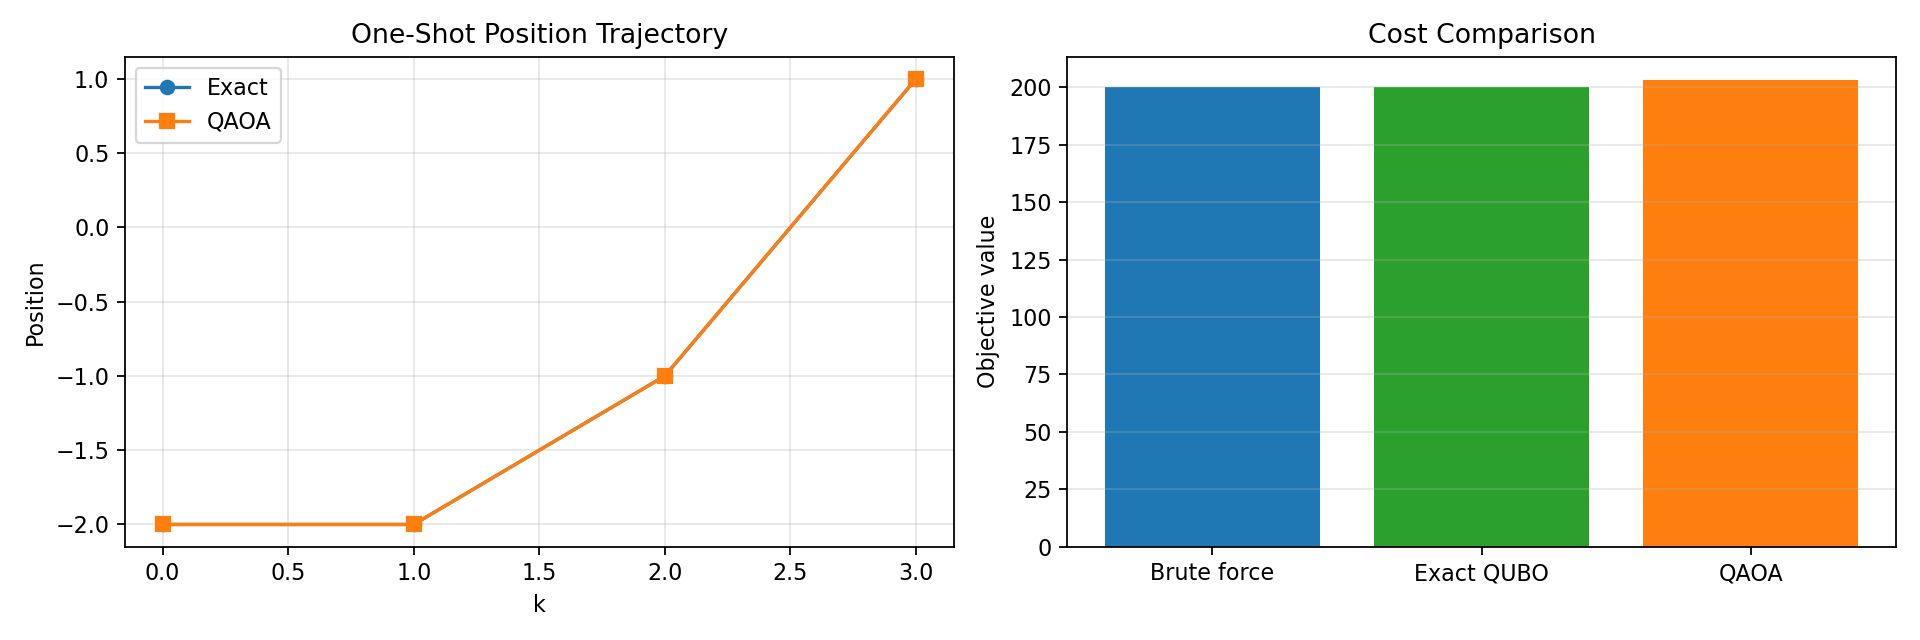

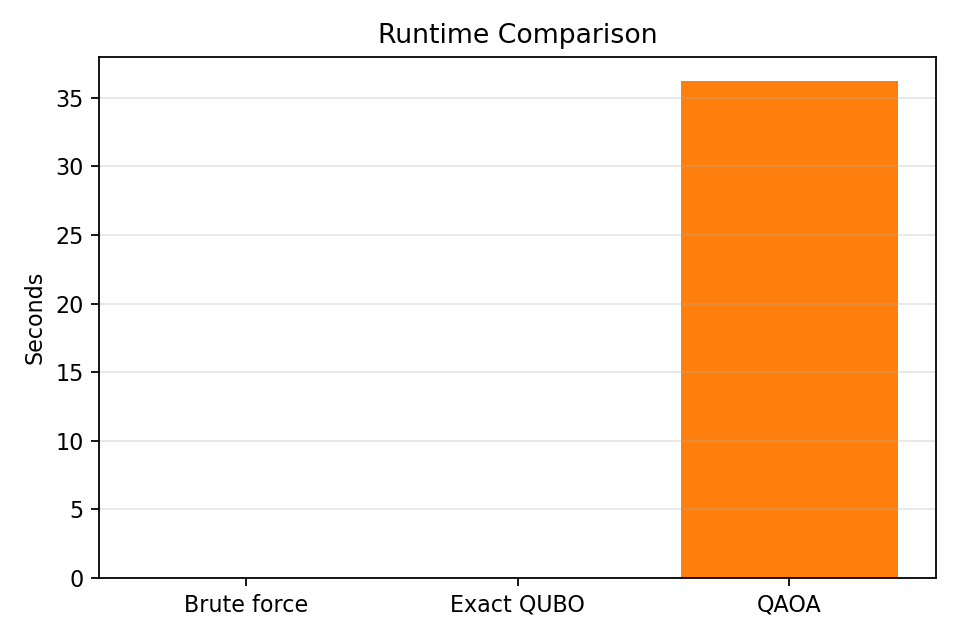

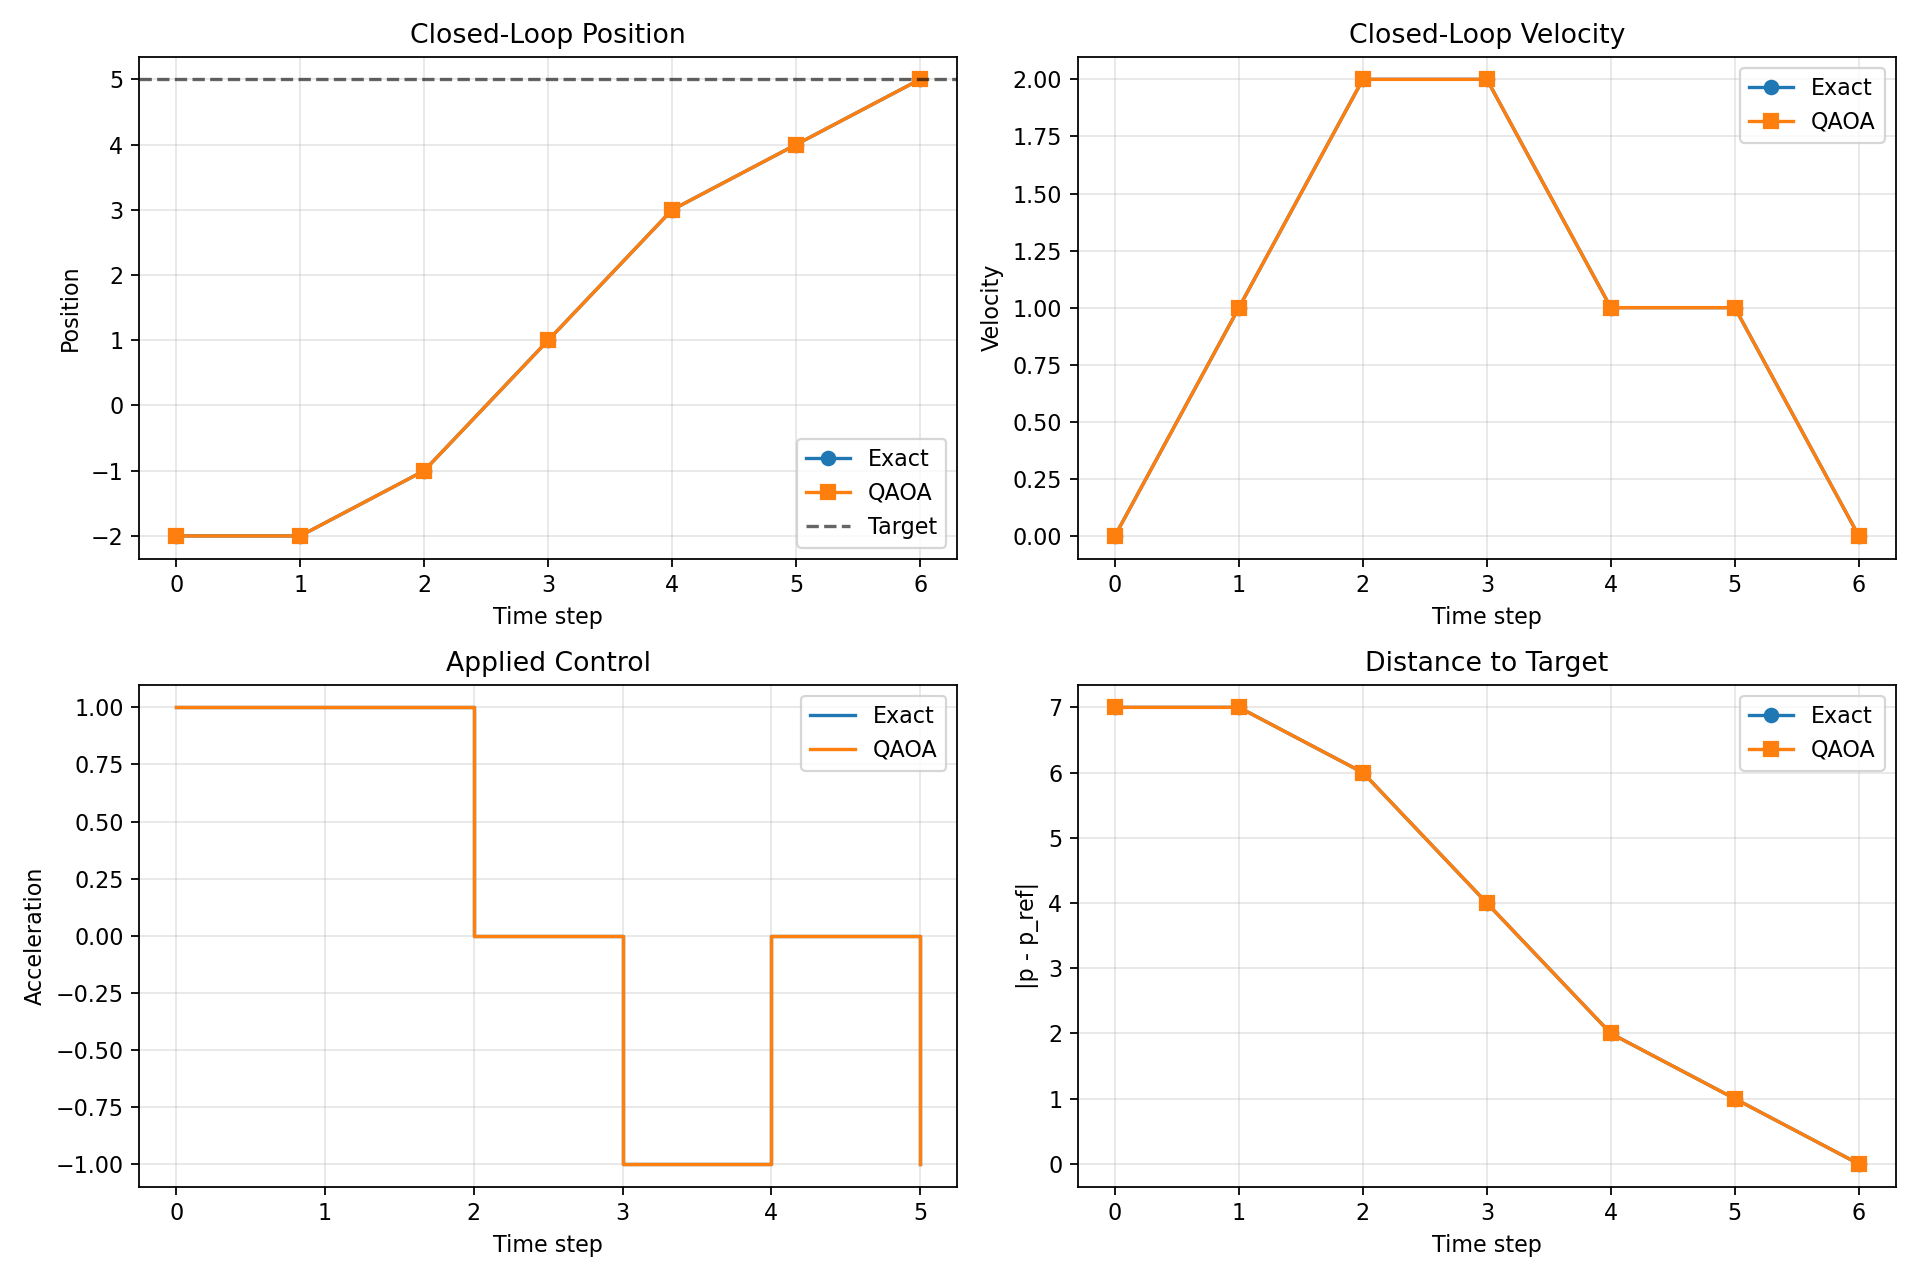

In [11]:
costs = {
    'Brute force': baseline.rollout.total_cost,
    'Exact QUBO': exact_outcome.mpc_cost,
    'QAOA': qaoa_outcome.mpc_cost,
}
runtimes = {
    'Brute force': baseline.runtime_s,
    'Exact QUBO': exact_outcome.runtime_s,
    'QAOA': qaoa_outcome.runtime_s,
}

save_one_shot_plots(
    output_dir,
    exact_rollout=baseline.rollout,
    qaoa_rollout=qaoa_outcome.rollout if qaoa_outcome.feasible else None,
    costs=costs,
    runtimes=runtimes,
)
save_closed_loop_plots(output_dir, exact_loop, qaoa_loop, params.p_ref)

display(Image(filename=str(output_dir / 'one_shot_summary.png')))
display(Image(filename=str(output_dir / 'runtime_comparison.png')))
display(Image(filename=str(output_dir / 'closed_loop_comparison.png')))

## 11. Optional GIF Animation

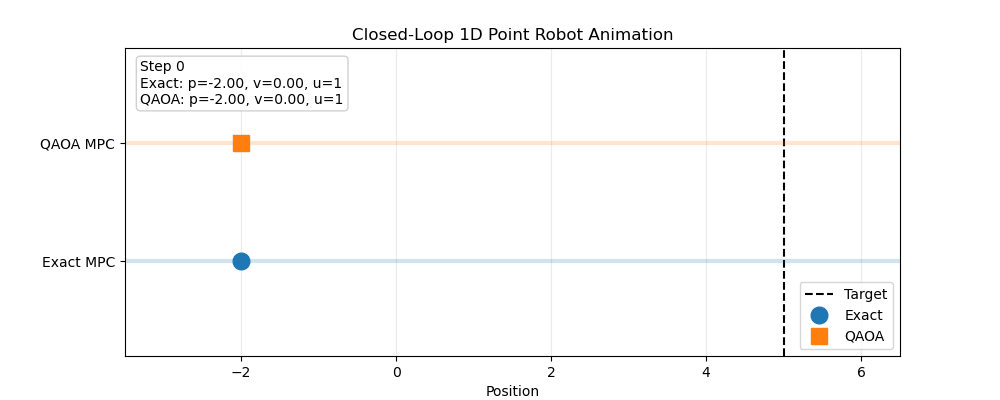

WindowsPath('outputs_mpc_qaoa_notebook/closed_loop_animation.gif')

In [12]:
gif_path = save_closed_loop_animation(output_dir, exact_loop, qaoa_loop, params.p_ref, fps=2)
display(Image(filename=str(gif_path)))
gif_path

In [13]:
gap = qaoa_outcome.mpc_cost - baseline.rollout.total_cost
rel_gap = gap / max(abs(baseline.rollout.total_cost), 1e-9)

summary = {
    'Horizon N': params.horizon,
    'Number of binary variables': 3 * params.horizon,
    'Best exact sequence': baseline.rollout.controls,
    'Best QAOA sequence': qaoa_outcome.controls,
    'Exact cost': baseline.rollout.total_cost,
    'Exact QUBO cost': exact_outcome.mpc_cost,
    'QAOA cost': qaoa_outcome.mpc_cost,
    'Relative gap': rel_gap,
    'QAOA feasible': qaoa_outcome.feasible,
}
summary

{'Horizon N': 3,
 'Number of binary variables': 9,
 'Best exact sequence': [1, 1, -1],
 'Best QAOA sequence': [1, 1, 0],
 'Exact cost': 200.3,
 'Exact QUBO cost': 200.3,
 'QAOA cost': 203.2,
 'Relative gap': 0.014478282576135681,
 'QAOA feasible': True}

## How This Maps to the Presentation

- **Robot model**: the notebook uses the 1D point-robot dynamics `p_{k+1} = p_k + dt v_k`, `v_{k+1} = v_k + dt a_k`.
- **Binary encoding**: each discrete action is encoded with one-hot variables `z_{k,-1}, z_{k,0}, z_{k,+1}`.
- **QUBO**: the finite-horizon MPC cost and one-hot penalties are assembled into a quadratic binary objective.
- **Ising Hamiltonian**: Qiskit converts the QUBO into a qubit Hamiltonian whose low-energy states correspond to good control sequences.
- **QAOA**: the approximate quantum workflow tries to prepare low-energy states of that Hamiltonian and is then compared with exact classical baselines.